In [ ]:
import tensorflow as tf, tf_keras
import numpy as np
from tensorflow.python.keras import activations
from tensorflow.python.keras import backend as K
from tensorflow.python.keras import constraints
from tensorflow.python.keras import initializers
from tensorflow.python.keras import regularizers
from tensorflow.python.keras.engine.base_layer import Layer
from tensorflow.python.keras.engine.input_spec import InputSpec
from tensorflow.python.keras.layers.recurrent import _standardize_args
from tensorflow.python.keras.layers.recurrent import DropoutRNNCellMixin
from tensorflow.python.keras.layers.recurrent import RNN
from tensorflow.python.keras.utils import conv_utils
from tensorflow.python.keras.utils import generic_utils
from tensorflow.python.keras.utils import tf_utils
from tensorflow.python.ops import array_ops
from tensorflow.python.util.tf_export import keras_export


class SepConvRNN2D(RNN):
  """Base class for seperable convolutional-recurrent layers.
  Arguments:
    cell: A RNN cell instance. A RNN cell is a class that has:
      - a `call(input_at_t, states_at_t)` method, returning
        `(output_at_t, states_at_t_plus_1)`. The call method of the
        cell can also take the optional argument `constants`, see
        section "Note on passing external constants" below.
      - a `state_size` attribute. This can be a single integer
        (single state) in which case it is
        the number of channels of the recurrent state
        (which should be the same as the number of channels of the cell
        output). This can also be a list/tuple of integers
        (one size per state). In this case, the first entry
        (`state_size[0]`) should be the same as
        the size of the cell output.
    return_sequences: Boolean. Whether to return the last output.
      in the output sequence, or the full sequence.
    return_state: Boolean. Whether to return the last state
      in addition to the output.
    go_backwards: Boolean (default False).
      If True, process the input sequence backwards and return the
      reversed sequence.
    stateful: Boolean (default False). If True, the last state
      for each sample at index i in a batch will be used as initial
      state for the sample of index i in the following batch.
    input_shape: Use this argument to specify the shape of the
      input when this layer is the first one in a model.
  Call arguments:
    inputs: A 5D tensor.
    mask: Binary tensor of shape `(samples, timesteps)` indicating whether
      a given timestep should be masked.
    training: Python boolean indicating whether the layer should behave in
      training mode or in inference mode. This argument is passed to the cell
      when calling it. This is for use with cells that use dropout.
    initial_state: List of initial state tensors to be passed to the first
      call of the cell.
    constants: List of constant tensors to be passed to the cell at each
      timestep.
  Input shape:
    5D tensor with shape:
    `(samples, timesteps, channels, rows, cols)`
    if data_format='channels_first' or 5D tensor with shape:
    `(samples, timesteps, rows, cols, channels)`
    if data_format='channels_last'.
  Output shape:
    - If `return_state`: a list of tensors. The first tensor is
      the output. The remaining tensors are the last states,
      each 4D tensor with shape:
      `(samples, filters, new_rows, new_cols)`
      if data_format='channels_first'
      or 4D tensor with shape:
      `(samples, new_rows, new_cols, filters)`
      if data_format='channels_last'.
      `rows` and `cols` values might have changed due to padding.
    - If `return_sequences`: 5D tensor with shape:
      `(samples, timesteps, filters, new_rows, new_cols)`
      if data_format='channels_first'
      or 5D tensor with shape:
      `(samples, timesteps, new_rows, new_cols, filters)`
      if data_format='channels_last'.
    - Else, 4D tensor with shape:
      `(samples, filters, new_rows, new_cols)`
      if data_format='channels_first'
      or 4D tensor with shape:
      `(samples, new_rows, new_cols, filters)`
      if data_format='channels_last'.
  Masking:
    This layer supports masking for input data with a variable number
    of timesteps.
  Note on using statefulness in RNNs:
    You can set RNN layers to be 'stateful', which means that the states
    computed for the samples in one batch will be reused as initial states
    for the samples in the next batch. This assumes a one-to-one mapping
    between samples in different successive batches.
    To enable statefulness:
      - Specify `stateful=True` in the layer constructor.
      - Specify a fixed batch size for your model, by passing
         - If sequential model:
            `batch_input_shape=(...)` to the first layer in your model.
         - If functional model with 1 or more Input layers:
            `batch_shape=(...)` to all the first layers in your model.
            This is the expected shape of your inputs
            *including the batch size*.
            It should be a tuple of integers,
            e.g. `(32, 10, 100, 100, 32)`.
            Note that the number of rows and columns should be specified
            too.
      - Specify `shuffle=False` when calling fit().
    To reset the states of your model, call `.reset_states()` on either
    a specific layer, or on your entire model.
  Note on specifying the initial state of RNNs:
    You can specify the initial state of RNN layers symbolically by
    calling them with the keyword argument `initial_state`. The value of
    `initial_state` should be a tensor or list of tensors representing
    the initial state of the RNN layer.
    You can specify the initial state of RNN layers numerically by
    calling `reset_states` with the keyword argument `states`. The value of
    `states` should be a numpy array or list of numpy arrays representing
    the initial state of the RNN layer.
  Note on passing external constants to RNNs:
    You can pass "external" constants to the cell using the `constants`
    keyword argument of `RNN.__call__` (as well as `RNN.call`) method. This
    requires that the `cell.call` method accepts the same keyword argument
    `constants`. Such constants can be used to condition the cell
    transformation on additional static inputs (not changing over time),
    a.k.a. an attention mechanism.
  """

  def __init__(self,
               cell,
               return_sequences=False,
               return_state=False,
               go_backwards=False,
               stateful=False,
               unroll=False,
               **kwargs):
    if unroll:
      raise TypeError('Unrolling isn\'t possible with '
                      'convolutional RNNs.')
    if isinstance(cell, (list, tuple)):
      # The StackedConvRNN2DCells isn't implemented yet.
      raise TypeError('It is not possible at the moment to'
                      'stack convolutional cells.')
    super(SepConvRNN2D, self).__init__(cell,
                                    return_sequences,
                                    return_state,
                                    go_backwards,
                                    stateful,
                                    unroll,
                                    **kwargs)
    self.input_spec = [InputSpec(ndim=5)]
    self.states = None
    self._num_constants = None

  @tf_utils.shape_type_conversion
  def compute_output_shape(self, input_shape):
    if isinstance(input_shape, list):
      input_shape = input_shape[0]

    cell = self.cell
    if cell.data_format == 'channels_first':
      rows = input_shape[3]
      cols = input_shape[4]
    elif cell.data_format == 'channels_last':
      rows = input_shape[2]
      cols = input_shape[3]
    rows = conv_utils.conv_output_length(rows,
                                         cell.kernel_size[0],
                                         padding=cell.padding,
                                         stride=cell.strides[0],
                                         dilation=cell.dilation_rate[0])
    cols = conv_utils.conv_output_length(cols,
                                         cell.kernel_size[1],
                                         padding=cell.padding,
                                         stride=cell.strides[1],
                                         dilation=cell.dilation_rate[1])

    if cell.data_format == 'channels_first':
      output_shape = input_shape[:2] + (cell.filters, rows, cols)
    elif cell.data_format == 'channels_last':
      output_shape = input_shape[:2] + (rows, cols, cell.filters)

    if not self.return_sequences:
      output_shape = output_shape[:1] + output_shape[2:]

    if self.return_state:
      output_shape = [output_shape]
      if cell.data_format == 'channels_first':
        output_shape += [(input_shape[0], cell.filters, rows, cols)
                         for _ in range(2)]
      elif cell.data_format == 'channels_last':
        output_shape += [(input_shape[0], rows, cols, cell.filters)
                         for _ in range(2)]
    return output_shape

  @tf_utils.shape_type_conversion
  def build(self, input_shape):
    # Note input_shape will be list of shapes of initial states and
    # constants if these are passed in __call__.
    if self._num_constants is not None:
      constants_shape = input_shape[-self._num_constants:]  # pylint: disable=E1130
    else:
      constants_shape = None

    if isinstance(input_shape, list):
      input_shape = input_shape[0]

    batch_size = input_shape[0] if self.stateful else None
    self.input_spec[0] = InputSpec(shape=(batch_size, None) + input_shape[2:5])

    # allow cell (if layer) to build before we set or validate state_spec
    if isinstance(self.cell, Layer):
      step_input_shape = (input_shape[0],) + input_shape[2:]
      if constants_shape is not None:
        self.cell.build([step_input_shape] + constants_shape)
      else:
        self.cell.build(step_input_shape)

    # set or validate state_spec
    if hasattr(self.cell.state_size, '__len__'):
      state_size = list(self.cell.state_size)
    else:
      state_size = [self.cell.state_size]

    if self.state_spec is not None:
      # initial_state was passed in call, check compatibility
      if self.cell.data_format == 'channels_first':
        ch_dim = 1
      elif self.cell.data_format == 'channels_last':
        ch_dim = 3
      if [spec.shape[ch_dim] for spec in self.state_spec] != state_size:
        raise ValueError(
            'An initial_state was passed that is not compatible with '
            '`cell.state_size`. Received `state_spec`={}; '
            'However `cell.state_size` is '
            '{}'.format([spec.shape for spec in self.state_spec],
                        self.cell.state_size))
    else:
      if self.cell.data_format == 'channels_first':
        self.state_spec = [InputSpec(shape=(None, dim, None, None))
                           for dim in state_size]
      elif self.cell.data_format == 'channels_last':
        self.state_spec = [InputSpec(shape=(None, None, None, dim))
                           for dim in state_size]
    if self.stateful:
      self.reset_states()
    self.built = True

  def get_initial_state(self, inputs):
    # (samples, timesteps, rows, cols, filters)
    initial_state = K.zeros_like(inputs)
    # (samples, rows, cols, filters)
    initial_state = K.sum(initial_state, axis=1)
    depth_shape = list(self.cell.depth_kernel_shape)
    depth_shape[-1] = self.cell.depth_multiplier
    point_shape = list(self.cell.point_kernel_shape)
    point_shape[-1] = self.cell.filters
    initial_state = self.cell.input_conv(initial_state,
                                         array_ops.zeros(tuple(depth_shape)),array_ops.zeros(tuple(point_shape)),
                                         padding=self.cell.padding)

    if hasattr(self.cell.state_size, '__len__'):
      return [initial_state for _ in self.cell.state_size]
    else:
      return [initial_state]

  def __call__(self, inputs, initial_state=None, constants=None, **kwargs):
    inputs, initial_state, constants = _standardize_args(
        inputs, initial_state, constants, self._num_constants)

    if initial_state is None and constants is None:
      return super(SepConvRNN2D, self).__call__(inputs, **kwargs)

    # If any of `initial_state` or `constants` are specified and are Keras
    # tensors, then add them to the inputs and temporarily modify the
    # input_spec to include them.

    additional_inputs = []
    additional_specs = []
    if initial_state is not None:
      kwargs['initial_state'] = initial_state
      additional_inputs += initial_state
      self.state_spec = []
      for state in initial_state:
        shape = K.int_shape(state)
        self.state_spec.append(InputSpec(shape=shape))

      additional_specs += self.state_spec
    if constants is not None:
      kwargs['constants'] = constants
      additional_inputs += constants
      self.constants_spec = [InputSpec(shape=K.int_shape(constant))
                             for constant in constants]
      self._num_constants = len(constants)
      additional_specs += self.constants_spec
    # at this point additional_inputs cannot be empty
    for tensor in additional_inputs:
      if K.is_keras_tensor(tensor) != K.is_keras_tensor(additional_inputs[0]):
        raise ValueError('The initial state or constants of an RNN'
                         ' layer cannot be specified with a mix of'
                         ' Keras tensors and non-Keras tensors')

    if K.is_keras_tensor(additional_inputs[0]):
      # Compute the full input spec, including state and constants
      full_input = [inputs] + additional_inputs
      full_input_spec = self.input_spec + additional_specs
      # Perform the call with temporarily replaced input_spec
      original_input_spec = self.input_spec
      self.input_spec = full_input_spec
      output = super(SepConvRNN2D, self).__call__(full_input, **kwargs)
      self.input_spec = original_input_spec
      return output
    else:
      return super(SepConvRNN2D, self).__call__(inputs, **kwargs)

  def call(self,inputs,mask=None,training=None,initial_state=None,constants=None):
    # note that the .build() method of subclasses MUST define
    # self.input_spec and self.state_spec with complete input shapes.
    if isinstance(inputs, list):
      inputs = inputs[0]
    if initial_state is not None:
      pass
    elif self.stateful:
      initial_state = self.states
    else:
      initial_state = self.get_initial_state(inputs)

    if isinstance(mask, list):
      mask = mask[0]

    if len(initial_state) != len(self.states):
      raise ValueError('Layer has ' + str(len(self.states)) +
                       ' states but was passed ' +
                       str(len(initial_state)) +
                       ' initial states.')
    timesteps = K.int_shape(inputs)[1]

    kwargs = {}
    if generic_utils.has_arg(self.cell.call, 'training'):
      kwargs['training'] = training

    if constants:
      if not generic_utils.has_arg(self.cell.call, 'constants'):
        raise ValueError('RNN cell does not support constants')

      def step(inputs, states):
        constants = states[-self._num_constants:]
        states = states[:-self._num_constants]
        return self.cell.call(inputs, states, constants=constants,
                              **kwargs)
    else:
      def step(inputs, states):
        return self.cell.call(inputs, states, **kwargs)

    last_output, outputs, states = K.rnn(step,
                                         inputs,
                                         initial_state,
                                         constants=constants,
                                         go_backwards=self.go_backwards,
                                         mask=mask,
                                         input_length=timesteps)
    if self.stateful:
      updates = []
      for i in range(len(states)):
        updates.append(K.update(self.states[i], states[i]))
      self.add_update(updates)

    if self.return_sequences:
      output = outputs
    else:
      output = last_output

    if self.return_state:
      if not isinstance(states, (list, tuple)):
        states = [states]
      else:
        states = list(states)
      return [output] + states
    else:
      return output

  def reset_states(self, states=None):
    if not self.stateful:
      raise AttributeError('Layer must be stateful.')
    input_shape = self.input_spec[0].shape
    state_shape = self.compute_output_shape(input_shape)
    if self.return_state:
      state_shape = state_shape[0]
    if self.return_sequences:
      state_shape = state_shape[:1].concatenate(state_shape[2:])
    if None in state_shape:
      raise ValueError('If a RNN is stateful, it needs to know '
                       'its batch size. Specify the batch size '
                       'of your input tensors: \n'
                       '- If using a Sequential model, '
                       'specify the batch size by passing '
                       'a `batch_input_shape` '
                       'argument to your first layer.\n'
                       '- If using the functional API, specify '
                       'the time dimension by passing a '
                       '`batch_shape` argument to your Input layer.\n'
                       'The same thing goes for the number of rows and '
                       'columns.')

    # helper function
    def get_tuple_shape(nb_channels):
      result = list(state_shape)
      if self.cell.data_format == 'channels_first':
        result[1] = nb_channels
      elif self.cell.data_format == 'channels_last':
        result[3] = nb_channels
      else:
        raise KeyError
      return tuple(result)

    # initialize state if None
    if self.states[0] is None:
      if hasattr(self.cell.state_size, '__len__'):
        self.states = [K.zeros(get_tuple_shape(dim))
                       for dim in self.cell.state_size]
      else:
        self.states = [K.zeros(get_tuple_shape(self.cell.state_size))]
    elif states is None:
      if hasattr(self.cell.state_size, '__len__'):
        for state, dim in zip(self.states, self.cell.state_size):
          K.set_value(state, np.zeros(get_tuple_shape(dim)))
      else:
        K.set_value(self.states[0],
                    np.zeros(get_tuple_shape(self.cell.state_size)))
    else:
      if not isinstance(states, (list, tuple)):
        states = [states]
      if len(states) != len(self.states):
        raise ValueError('Layer ' + self.name + ' expects ' +
                         str(len(self.states)) + ' states, ' +
                         'but it received ' + str(len(states)) +
                         ' state values. Input received: ' + str(states))
      for index, (value, state) in enumerate(zip(states, self.states)):
        if hasattr(self.cell.state_size, '__len__'):
          dim = self.cell.state_size[index]
        else:
          dim = self.cell.state_size
        if value.shape != get_tuple_shape(dim):
          raise ValueError('State ' + str(index) +
                           ' is incompatible with layer ' +
                           self.name + ': expected shape=' +
                           str(get_tuple_shape(dim)) +
                           ', found shape=' + str(value.shape))
        # TODO(anjalisridhar): consider batch calls to `set_value`.
        K.set_value(state, value)


class SepConvLSTM2DCell(DropoutRNNCellMixin, Layer):
  """Cell class for the SepConvLSTM2D layer.
  Arguments:
    filters: Integer, the dimensionality of the output space
      (i.e. the number of output filters in the convolution).
    kernel_size: An integer or tuple/list of n integers, specifying the
      dimensions of the convolution window.
    strides: An integer or tuple/list of n integers,
      specifying the strides of the convolution.
      Specifying any stride value != 1 is incompatible with specifying
      any `dilation_rate` value != 1.
    padding: One of `"valid"` or `"same"` (case-insensitive).
    data_format: A string,
      one of `channels_last` (default) or `channels_first`.
      It defaults to the `image_data_format` value found in your
      Keras config file at `~/.keras/keras.json`.
      If you never set it, then it will be "channels_last".
    dilation_rate: An integer or tuple/list of n integers, specifying
      the dilation rate to use for dilated convolution.
      Currently, specifying any `dilation_rate` value != 1 is
      incompatible with specifying any `strides` value != 1.
    depth_multiplier: The number of depthwise convolution output channels
      for each input channel. The total number of depthwise convolution output channels
      will be equal to filters_in * depth_multiplier
    activation: Activation function to use.
      If you don't specify anything, no activation is applied
      (ie. "linear" activation: `a(x) = x`).
    recurrent_activation: Activation function to use
      for the recurrent step.
    use_bias: Boolean, whether the layer uses a bias vector.
    kernel_initializer: Initializer for the `kernel` weights matrix,
      used for the linear transformation of the inputs.
    recurrent_initializer: Initializer for the `recurrent_kernel`
      weights matrix,
      used for the linear transformation of the recurrent state.
    bias_initializer: Initializer for the bias vector.
    unit_forget_bias: Boolean.
      If True, add 1 to the bias of the forget gate at initialization.
      Use in combination with `bias_initializer="zeros"`.
      This is recommended in [Jozefowicz et al.]
      (http://www.jmlr.org/proceedings/papers/v37/jozefowicz15.pdf)
    kernel_regularizer: Regularizer function applied to
      the `kernel` weights matrix.
    recurrent_regularizer: Regularizer function applied to
      the `recurrent_kernel` weights matrix.
    bias_regularizer: Regularizer function applied to the bias vector.
    kernel_constraint: Constraint function applied to
      the `kernel` weights matrix.
    recurrent_constraint: Constraint function applied to
      the `recurrent_kernel` weights matrix.
    bias_constraint: Constraint function applied to the bias vector.
    dropout: Float between 0 and 1.
      Fraction of the units to drop for
      the linear transformation of the inputs.
    recurrent_dropout: Float between 0 and 1.
      Fraction of the units to drop for
      the linear transformation of the recurrent state.
  Call arguments:
    inputs: A 4D tensor.
    states:  List of state tensors corresponding to the previous timestep.
    training: Python boolean indicating whether the layer should behave in
      training mode or in inference mode. Only relevant when `dropout` or
      `recurrent_dropout` is used.
  """

  def __init__(self,
               filters,
               kernel_size,
               strides=(1, 1),
               padding='valid',
               data_format=None,
               dilation_rate=(1, 1),
               depth_multiplier = 1,
               activation='tanh',
               recurrent_activation='hard_sigmoid',
               use_bias=True,
               kernel_initializer='glorot_uniform',
               recurrent_initializer='orthogonal',
               bias_initializer='zeros',
               unit_forget_bias=True,
               kernel_regularizer=None,
               recurrent_regularizer=None,
               bias_regularizer=None,
               kernel_constraint=None,
               recurrent_constraint=None,
               bias_constraint=None,
               dropout=0.,
               recurrent_dropout=0.,
               **kwargs):
    super(SepConvLSTM2DCell, self).__init__(**kwargs)
    self.filters = filters
    self.kernel_size = conv_utils.normalize_tuple(kernel_size, 2, 'kernel_size')
    self.strides = conv_utils.normalize_tuple(strides, 2, 'strides')
    self.padding = conv_utils.normalize_padding(padding)
    self.data_format = conv_utils.normalize_data_format(data_format)
    self.dilation_rate = conv_utils.normalize_tuple(dilation_rate, 2,
                                                    'dilation_rate')
    self.depth_multiplier = depth_multiplier
    self.activation = activations.get(activation)
    self.recurrent_activation = activations.get(recurrent_activation)
    self.use_bias = use_bias

    self.kernel_initializer = initializers.get(kernel_initializer)
    self.recurrent_initializer = initializers.get(recurrent_initializer)
    self.bias_initializer = initializers.get(bias_initializer)
    self.unit_forget_bias = unit_forget_bias

    self.kernel_regularizer = regularizers.get(kernel_regularizer)
    self.recurrent_regularizer = regularizers.get(recurrent_regularizer)
    self.bias_regularizer = regularizers.get(bias_regularizer)

    self.kernel_constraint = constraints.get(kernel_constraint)
    self.recurrent_constraint = constraints.get(recurrent_constraint)
    self.bias_constraint = constraints.get(bias_constraint)

    self.dropout = min(1., max(0., dropout))
    self.recurrent_dropout = min(1., max(0., recurrent_dropout))
    self.state_size = (self.filters, self.filters)

  def build(self, input_shape):

    if self.data_format == 'channels_first':
      channel_axis = 1
    else:
      channel_axis = -1
    if input_shape[channel_axis] is None:
      raise ValueError('The channel dimension of the inputs '
                       'should be defined. Found `None`.')
    input_dim = input_shape[channel_axis]
    depth_kernel_shape = self.kernel_size + ( input_dim, self.depth_multiplier * 4)
    point_kernel_shape = (1,1) + ( input_dim * self.depth_multiplier, self.filters * 4)

    self.depth_kernel_shape = depth_kernel_shape
    self.point_kernel_shape = point_kernel_shape

    recurrent_depth_kernel_shape = self.kernel_size + ( self.filters , self.depth_multiplier * 4 )
    recurrent_point_kernel_shape = (1,1) + ( self.filters * self.depth_multiplier , self.filters * 4 )

    self.depth_kernel_shape = depth_kernel_shape
    self.point_kernel_shape = point_kernel_shape


    self.depth_kernel = self.add_weight(shape=depth_kernel_shape,
                                        initializer=self.kernel_initializer,
                                        name='depth_kernel',
                                        regularizer=self.kernel_regularizer,
                                        constraint=self.kernel_constraint)

    self.point_kernel = self.add_weight(shape=point_kernel_shape,
                                        initializer=self.kernel_initializer,
                                        name='point_kernel',
                                        regularizer=self.kernel_regularizer,
                                        constraint=self.kernel_constraint)


    self.recurrent_depth_kernel = self.add_weight(
                                        shape=recurrent_depth_kernel_shape,
                                        initializer=self.recurrent_initializer,
                                        name='recurrent_depth_kernel',
                                        regularizer=self.recurrent_regularizer,
                                        constraint=self.recurrent_constraint)

    self.recurrent_point_kernel = self.add_weight(
                                        shape=recurrent_point_kernel_shape,
                                        initializer=self.recurrent_initializer,
                                        name='recurrent_point_kernel',
                                        regularizer=self.recurrent_regularizer,
                                        constraint=self.recurrent_constraint)


    if self.use_bias:
      if self.unit_forget_bias:

        def bias_initializer(_, *args, **kwargs):
          return K.concatenate([
              self.bias_initializer((self.filters,), *args, **kwargs),
              initializers.Ones()((self.filters,), *args, **kwargs),
              self.bias_initializer((self.filters * 2,), *args, **kwargs),
          ])
      else:
        bias_initializer = self.bias_initializer
      self.bias = self.add_weight(
          shape=(self.filters * 4,),
          name='bias',
          initializer=bias_initializer,
          regularizer=self.bias_regularizer,
          constraint=self.bias_constraint)
    else:
      self.bias = None
    self.built = True

  def call(self, inputs, states, training=None):
    h_tm1 = states[0]  # previous memory state
    c_tm1 = states[1]  # previous carry state

    # dropout matrices for input units
    dp_mask = self.get_dropout_mask_for_cell(inputs, training, count=4)
    # dropout matrices for recurrent units
    rec_dp_mask = self.get_recurrent_dropout_mask_for_cell(
        h_tm1, training, count=4)

    if 0 < self.dropout < 1.:
      inputs_i = inputs * dp_mask[0]
      inputs_f = inputs * dp_mask[1]
      inputs_c = inputs * dp_mask[2]
      inputs_o = inputs * dp_mask[3]
    else:
      inputs_i = inputs
      inputs_f = inputs
      inputs_c = inputs
      inputs_o = inputs

    if 0 < self.recurrent_dropout < 1.:
      h_tm1_i = h_tm1 * rec_dp_mask[0]
      h_tm1_f = h_tm1 * rec_dp_mask[1]
      h_tm1_c = h_tm1 * rec_dp_mask[2]
      h_tm1_o = h_tm1 * rec_dp_mask[3]
    else:
      h_tm1_i = h_tm1
      h_tm1_f = h_tm1
      h_tm1_c = h_tm1
      h_tm1_o = h_tm1

    (depth_kernel_i, depth_kernel_f,
     depth_kernel_c, depth_kernel_o) = array_ops.split(self.depth_kernel, 4, axis=3)
    (recurrent_depth_kernel_i,
     recurrent_depth_kernel_f,
     recurrent_depth_kernel_c,
     recurrent_depth_kernel_o) = array_ops.split(self.recurrent_depth_kernel, 4, axis=3)

    (point_kernel_i, point_kernel_f,
     point_kernel_c, point_kernel_o) = array_ops.split(self.point_kernel, 4, axis=3)
    (recurrent_point_kernel_i,
     recurrent_point_kernel_f,
     recurrent_point_kernel_c,
     recurrent_point_kernel_o) = array_ops.split(self.recurrent_point_kernel, 4, axis=3)

    if self.use_bias:
      bias_i, bias_f, bias_c, bias_o = array_ops.split(self.bias, 4)
    else:
      bias_i, bias_f, bias_c, bias_o = None, None, None, None

    x_i = self.input_conv(inputs_i, depth_kernel_i, point_kernel_i, bias_i, padding=self.padding)
    x_f = self.input_conv(inputs_f, depth_kernel_f, point_kernel_f, bias_f, padding=self.padding)
    x_c = self.input_conv(inputs_c, depth_kernel_c, point_kernel_c, bias_c, padding=self.padding)
    x_o = self.input_conv(inputs_o, depth_kernel_o, point_kernel_o, bias_o, padding=self.padding)
    h_i = self.recurrent_conv(h_tm1_i, recurrent_depth_kernel_i, recurrent_point_kernel_i)
    h_f = self.recurrent_conv(h_tm1_f, recurrent_depth_kernel_f, recurrent_point_kernel_f)
    h_c = self.recurrent_conv(h_tm1_c, recurrent_depth_kernel_c, recurrent_point_kernel_c)
    h_o = self.recurrent_conv(h_tm1_o, recurrent_depth_kernel_o, recurrent_point_kernel_o)

    i = self.recurrent_activation(x_i + h_i)
    f = self.recurrent_activation(x_f + h_f)
    c = f * c_tm1 + i * self.activation(x_c + h_c)
    o = self.recurrent_activation(x_o + h_o)
    h = o * self.activation(c)
    return h, [h, c]

  def input_conv(self, x, dw, pw, b=None, padding='valid'):
    conv_out = K.separable_conv2d(x, dw, pw, strides=self.strides,
                            padding=padding,
                            data_format=self.data_format,
                            dilation_rate=self.dilation_rate)
    if b is not None:
      conv_out = K.bias_add(conv_out, b,
                                  data_format=self.data_format)
    return conv_out

  def recurrent_conv(self, x, dw, pw):
    conv_out = K.separable_conv2d(x, dw, pw, strides=(1, 1),
                            padding='same',
                            data_format=self.data_format)
    return conv_out

  def get_config(self):
    config = {'filters': self.filters,
              'kernel_size': self.kernel_size,
              'strides': self.strides,
              'padding': self.padding,
              'data_format': self.data_format,
              'dilation_rate': self.dilation_rate,
              'depth_multiplier':self.depth_multiplier,
              'activation': activations.serialize(self.activation),
              'recurrent_activation': activations.serialize(
                  self.recurrent_activation),
              'use_bias': self.use_bias,
              'kernel_initializer': initializers.serialize(
                  self.kernel_initializer),
              'recurrent_initializer': initializers.serialize(
                  self.recurrent_initializer),
              'bias_initializer': initializers.serialize(self.bias_initializer),
              'unit_forget_bias': self.unit_forget_bias,
              'kernel_regularizer': regularizers.serialize(
                  self.kernel_regularizer),
              'recurrent_regularizer': regularizers.serialize(
                  self.recurrent_regularizer),
              'bias_regularizer': regularizers.serialize(self.bias_regularizer),
              'kernel_constraint': constraints.serialize(
                  self.kernel_constraint),
              'recurrent_constraint': constraints.serialize(
                  self.recurrent_constraint),
              'bias_constraint': constraints.serialize(self.bias_constraint),
              'dropout': self.dropout,
              'recurrent_dropout': self.recurrent_dropout}
    base_config = super(SepConvLSTM2DCell, self).get_config()
    return dict(list(base_config.items()) + list(config.items()))


@keras_export('keras.layers.SepConvLSTM2D')
class SepConvLSTM2D(SepConvRNN2D):
  """Seperable Convolutional LSTM.
  It is similar to an LSTM layer, but the input transformations
  and recurrent transformations are both depthwise seperable convolutional.
  Arguments:
    filters: Integer, the dimensionality of the output space
      (i.e. the number of output filters in the convolution).
    kernel_size: An integer or tuple/list of n integers, specifying the
      dimensions of the convolution window.
    strides: An integer or tuple/list of n integers,
      specifying the strides of the convolution.
      Specifying any stride value != 1 is incompatible with specifying
      any `dilation_rate` value != 1.
    padding: One of `"valid"` or `"same"` (case-insensitive).
    data_format: A string,
      one of `channels_last` (default) or `channels_first`.
      The ordering of the dimensions in the inputs.
      `channels_last` corresponds to inputs with shape
      `(batch, time, ..., channels)`
      while `channels_first` corresponds to
      inputs with shape `(batch, time, channels, ...)`.
      It defaults to the `image_data_format` value found in your
      Keras config file at `~/.keras/keras.json`.
      If you never set it, then it will be "channels_last".
    dilation_rate: An integer or tuple/list of n integers, specifying
      the dilation rate to use for dilated convolution.
      Currently, specifying any `dilation_rate` value != 1 is
      incompatible with specifying any `strides` value != 1.
    depth_multiplier: The number of depthwise convolution output channels
      for each input channel. The total number of depthwise convolution output channels
      will be equal to filters_in * depth_multiplier
    activation: Activation function to use.
      By default hyperbolic tangent activation function is applied
      (`tanh(x)`).
    recurrent_activation: Activation function to use
      for the recurrent step.
    use_bias: Boolean, whether the layer uses a bias vector.
    kernel_initializer: Initializer for the `kernel` weights matrix,
      used for the linear transformation of the inputs.
    recurrent_initializer: Initializer for the `recurrent_kernel`
      weights matrix,
      used for the linear transformation of the recurrent state.
    bias_initializer: Initializer for the bias vector.
    unit_forget_bias: Boolean.
      If True, add 1 to the bias of the forget gate at initialization.
      Use in combination with `bias_initializer="zeros"`.
      This is recommended in [Jozefowicz et al.]
      (http://www.jmlr.org/proceedings/papers/v37/jozefowicz15.pdf)
    kernel_regularizer: Regularizer function applied to
      the `kernel` weights matrix.
    recurrent_regularizer: Regularizer function applied to
      the `recurrent_kernel` weights matrix.
    bias_regularizer: Regularizer function applied to the bias vector.
    activity_regularizer: Regularizer function applied to.
    kernel_constraint: Constraint function applied to
      the `kernel` weights matrix.
    recurrent_constraint: Constraint function applied to
      the `recurrent_kernel` weights matrix.
    bias_constraint: Constraint function applied to the bias vector.
    return_sequences: Boolean. Whether to return the last output
      in the output sequence, or the full sequence.
    go_backwards: Boolean (default False).
      If True, process the input sequence backwards.
    stateful: Boolean (default False). If True, the last state
      for each sample at index i in a batch will be used as initial
      state for the sample of index i in the following batch.
    dropout: Float between 0 and 1.
      Fraction of the units to drop for
      the linear transformation of the inputs.
    recurrent_dropout: Float between 0 and 1.
      Fraction of the units to drop for
      the linear transformation of the recurrent state.
  Call arguments:
    inputs: A 5D tensor.
    mask: Binary tensor of shape `(samples, timesteps)` indicating whether
      a given timestep should be masked.
    training: Python boolean indicating whether the layer should behave in
      training mode or in inference mode. This argument is passed to the cell
      when calling it. This is only relevant if `dropout` or `recurrent_dropout`
      are set.
    initial_state: List of initial state tensors to be passed to the first
      call of the cell.
  Input shape:
    - If data_format='channels_first'
        5D tensor with shape:
        `(samples, time, channels, rows, cols)`
    - If data_format='channels_last'
        5D tensor with shape:
        `(samples, time, rows, cols, channels)`
  Output shape:
    - If `return_sequences`
       - If data_format='channels_first'
          5D tensor with shape:
          `(samples, time, filters, output_row, output_col)`
       - If data_format='channels_last'
          5D tensor with shape:
          `(samples, time, output_row, output_col, filters)`
    - Else
      - If data_format ='channels_first'
          4D tensor with shape:
          `(samples, filters, output_row, output_col)`
      - If data_format='channels_last'
          4D tensor with shape:
          `(samples, output_row, output_col, filters)`
      where `o_row` and `o_col` depend on the shape of the filter and
      the padding
  Raises:
    ValueError: in case of invalid constructor arguments.
  References:
    - [Convolutional LSTM Network: A Machine Learning Approach for
    Precipitation Nowcasting](http://arxiv.org/abs/1506.04214v1)
    The current implementation does not include the feedback loop on the
    cells output.
  """

  def __init__(self,
               filters,
               kernel_size,
               strides=(1, 1),
               padding='valid',
               data_format=None,
               dilation_rate=(1, 1),
               depth_multiplier = 1,
               activation='tanh',
               recurrent_activation='hard_sigmoid',
               use_bias=True,
               kernel_initializer='glorot_uniform',
               recurrent_initializer='orthogonal',
               bias_initializer='zeros',
               unit_forget_bias=True,
               kernel_regularizer=None,
               recurrent_regularizer=None,
               bias_regularizer=None,
               activity_regularizer=None,
               kernel_constraint=None,
               recurrent_constraint=None,
               bias_constraint=None,
               return_sequences=False,
               go_backwards=False,
               stateful=False,
               dropout=0.,
               recurrent_dropout=0.,
               **kwargs):
    cell = SepConvLSTM2DCell(filters=filters,
                          kernel_size=kernel_size,
                          strides=strides,
                          padding=padding,
                          data_format=data_format,
                          dilation_rate=dilation_rate,
                          depth_multiplier=depth_multiplier,
                          activation=activation,
                          recurrent_activation=recurrent_activation,
                          use_bias=use_bias,
                          kernel_initializer=kernel_initializer,
                          recurrent_initializer=recurrent_initializer,
                          bias_initializer=bias_initializer,
                          unit_forget_bias=unit_forget_bias,
                          kernel_regularizer=kernel_regularizer,
                          recurrent_regularizer=recurrent_regularizer,
                          bias_regularizer=bias_regularizer,
                          kernel_constraint=kernel_constraint,
                          recurrent_constraint=recurrent_constraint,
                          bias_constraint=bias_constraint,
                          dropout=dropout,
                          recurrent_dropout=recurrent_dropout,
                          dtype=kwargs.get('dtype'))
    super(SepConvLSTM2D, self).__init__(cell,
                                     return_sequences=return_sequences,
                                     go_backwards=go_backwards,
                                     stateful=stateful,
                                     **kwargs)
    self.activity_regularizer = regularizers.get(activity_regularizer)

  def call(self, inputs, mask=None, training=None, initial_state=None):
    self._maybe_reset_cell_dropout_mask(self.cell)
    return super(SepConvLSTM2D, self).call(inputs,
                                        mask=mask,
                                        training=training,
                                        initial_state=initial_state)

  @property
  def filters(self):
    return self.cell.filters

  @property
  def kernel_size(self):
    return self.cell.kernel_size

  @property
  def strides(self):
    return self.cell.strides

  @property
  def padding(self):
    return self.cell.padding

  @property
  def data_format(self):
    return self.cell.data_format

  @property
  def dilation_rate(self):
    return self.cell.dilation_rate

  @property
  def depth_multiplier(self):
    return self.cell.depth_multiplier

  @property
  def activation(self):
    return self.cell.activation

  @property
  def recurrent_activation(self):
    return self.cell.recurrent_activation

  @property
  def use_bias(self):
    return self.cell.use_bias

  @property
  def kernel_initializer(self):
    return self.cell.kernel_initializer

  @property
  def recurrent_initializer(self):
    return self.cell.recurrent_initializer

  @property
  def bias_initializer(self):
    return self.cell.bias_initializer

  @property
  def unit_forget_bias(self):
    return self.cell.unit_forget_bias

  @property
  def kernel_regularizer(self):
    return self.cell.kernel_regularizer

  @property
  def recurrent_regularizer(self):
    return self.cell.recurrent_regularizer

  @property
  def bias_regularizer(self):
    return self.cell.bias_regularizer

  @property
  def kernel_constraint(self):
    return self.cell.kernel_constraint

  @property
  def recurrent_constraint(self):
    return self.cell.recurrent_constraint

  @property
  def bias_constraint(self):
    return self.cell.bias_constraint

  @property
  def dropout(self):
    return self.cell.dropout

  @property
  def recurrent_dropout(self):
    return self.cell.recurrent_dropout

  def get_config(self):
    config = {'filters': self.filters,
              'kernel_size': self.kernel_size,
              'strides': self.strides,
              'padding': self.padding,
              'data_format': self.data_format,
              'dilation_rate': self.dilation_rate,
              'depth_multiplier':self.depth_multiplier,
              'activation': activations.serialize(self.activation),
              'recurrent_activation': activations.serialize(
                  self.recurrent_activation),
              'use_bias': self.use_bias,
              'kernel_initializer': initializers.serialize(
                  self.kernel_initializer),
              'recurrent_initializer': initializers.serialize(
                  self.recurrent_initializer),
              'bias_initializer': initializers.serialize(self.bias_initializer),
              'unit_forget_bias': self.unit_forget_bias,
              'kernel_regularizer': regularizers.serialize(
                  self.kernel_regularizer),
              'recurrent_regularizer': regularizers.serialize(
                  self.recurrent_regularizer),
              'bias_regularizer': regularizers.serialize(self.bias_regularizer),
              'activity_regularizer': regularizers.serialize(
                  self.activity_regularizer),
              'kernel_constraint': constraints.serialize(
                  self.kernel_constraint),
              'recurrent_constraint': constraints.serialize(
                  self.recurrent_constraint),
              'bias_constraint': constraints.serialize(self.bias_constraint),
              'dropout': self.dropout,
              'recurrent_dropout': self.recurrent_dropout}
    base_config = super(SepConvLSTM2D, self).get_config()
    del base_config['cell']
    return dict(list(base_config.items()) + list(config.items()))

  @classmethod
  def from_config(cls, config):
    return cls(**config)



class AttenSepConvLSTM2DCell(DropoutRNNCellMixin, Layer):

  def __init__(self,
               filters,
               kernel_size,
               strides=(1, 1),
               padding='valid',
               data_format=None,
               dilation_rate=(1, 1),
               depth_multiplier = 1,
               activation='tanh',
               recurrent_activation='hard_sigmoid',
               use_bias=True,
               kernel_initializer='glorot_uniform',
               recurrent_initializer='orthogonal',
               bias_initializer='zeros',
               unit_forget_bias=True,
               kernel_regularizer=None,
               recurrent_regularizer=None,
               bias_regularizer=None,
               kernel_constraint=None,
               recurrent_constraint=None,
               bias_constraint=None,
               dropout=0.,
               recurrent_dropout=0.,
               **kwargs):
    super(AttenSepConvLSTM2DCell, self).__init__(**kwargs)
    self.filters = filters
    self.kernel_size = conv_utils.normalize_tuple(kernel_size, 2, 'kernel_size')
    self.strides = conv_utils.normalize_tuple(strides, 2, 'strides')
    self.padding = conv_utils.normalize_padding(padding)
    self.data_format = conv_utils.normalize_data_format(data_format)
    self.dilation_rate = conv_utils.normalize_tuple(dilation_rate, 2,'dilation_rate')
    self.depth_multiplier = depth_multiplier
    self.activation = activations.get(activation)
    self.recurrent_activation = activations.get(recurrent_activation)
    self.use_bias = use_bias

    self.kernel_initializer = initializers.get(kernel_initializer)
    self.recurrent_initializer = initializers.get(recurrent_initializer)
    self.bias_initializer = initializers.get(bias_initializer)
    self.unit_forget_bias = unit_forget_bias

    self.kernel_regularizer = regularizers.get(kernel_regularizer)
    self.recurrent_regularizer = regularizers.get(recurrent_regularizer)
    self.bias_regularizer = regularizers.get(bias_regularizer)

    self.kernel_constraint = constraints.get(kernel_constraint)
    self.recurrent_constraint = constraints.get(recurrent_constraint)
    self.bias_constraint = constraints.get(bias_constraint)

    self.dropout = min(1., max(0., dropout))
    self.recurrent_dropout = min(1., max(0., recurrent_dropout))
    self.state_size = (self.filters, self.filters)

  def build(self, input_shape):

    if self.data_format == 'channels_first':
      channel_axis = 1
    else:
      channel_axis = -1
    if input_shape[channel_axis] is None:
      raise ValueError('The channel dimension of the inputs '
                       'should be defined. Found `None`.')
    # print('>>>>>>>>>>>>>>>> ', input_shape)
    self.feat_shape = input_shape #(input_shape[0], input_shape[1], input_shape[2], input_shape[3])
    input_dim = input_shape[channel_axis]
    depth_kernel_shape = self.kernel_size + ( input_dim, self.depth_multiplier * 4)
    point_kernel_shape = (1,1) + ( input_dim * self.depth_multiplier, self.filters * 4)
    depth_kernel_a_shape = self.kernel_size + ( input_dim, self.depth_multiplier)
    point_kernel_a_shape = (1,1) + ( input_dim * self.depth_multiplier, input_dim)


    self.depth_kernel_shape = depth_kernel_shape
    self.point_kernel_shape = point_kernel_shape

    recurrent_depth_kernel_shape = self.kernel_size + ( self.filters , self.depth_multiplier * 4 )
    recurrent_point_kernel_shape = (1,1) + ( self.filters * self.depth_multiplier , self.filters * 4 )
    recurrent_depth_kernel_a_shape = self.kernel_size + ( self.filters, self.depth_multiplier)
    recurrent_point_kernel_a_shape = (1,1) + ( self.filters * self.depth_multiplier, input_dim)

    self.recurrent_depth_kernel_shape = depth_kernel_shape
    self.recurrent_point_kernel_shape = point_kernel_shape


    self.depth_kernel = self.add_weight(shape=depth_kernel_shape,
                                        initializer=self.kernel_initializer,
                                        name='depth_kernel',
                                        regularizer=self.kernel_regularizer,
                                        constraint=self.kernel_constraint)

    self.point_kernel = self.add_weight(shape=point_kernel_shape,
                                        initializer=self.kernel_initializer,
                                        name='point_kernel',
                                        regularizer=self.kernel_regularizer,
                                        constraint=self.kernel_constraint)

    self.depth_kernel_a = self.add_weight(shape=depth_kernel_a_shape,
                                        initializer=self.kernel_initializer,
                                        name='depth_kernel_a',
                                        regularizer=self.kernel_regularizer,
                                        constraint=self.kernel_constraint)

    self.point_kernel_a = self.add_weight(shape=point_kernel_a_shape,
                                        initializer=self.kernel_initializer,
                                        name='point_kernel_a',
                                        regularizer=self.kernel_regularizer,
                                        constraint=self.kernel_constraint)

    self.recurrent_depth_kernel = self.add_weight(
                                        shape=recurrent_depth_kernel_shape,
                                        initializer=self.recurrent_initializer,
                                        name='recurrent_depth_kernel',
                                        regularizer=self.recurrent_regularizer,
                                        constraint=self.recurrent_constraint)

    self.recurrent_point_kernel = self.add_weight(
                                        shape=recurrent_point_kernel_shape,
                                        initializer=self.recurrent_initializer,
                                        name='recurrent_point_kernel',
                                        regularizer=self.recurrent_regularizer,
                                        constraint=self.recurrent_constraint)
    self.recurrent_depth_kernel_a = self.add_weight(
                                        shape=recurrent_depth_kernel_a_shape,
                                        initializer=self.recurrent_initializer,
                                        name='recurrent_depth_kernel_a',
                                        regularizer=self.recurrent_regularizer,
                                        constraint=self.recurrent_constraint)

    self.recurrent_point_kernel_a = self.add_weight(
                                        shape=recurrent_point_kernel_a_shape,
                                        initializer=self.recurrent_initializer,
                                        name='recurrent_point_kernel_a',
                                        regularizer=self.recurrent_regularizer,
                                        constraint=self.recurrent_constraint)

    self.attention_weight = self.add_weight(
        shape=self.kernel_size+(input_dim, 1),
        initializer=self.kernel_initializer,
        name='attention_weight',
        regularizer=self.kernel_regularizer,
        constraint=self.kernel_constraint)

    if self.use_bias:
      if self.unit_forget_bias:
        def bias_initializer(_, *args, **kwargs):
          return K.concatenate([
              self.bias_initializer((self.filters,), *args, **kwargs),
              initializers.Ones()((self.filters,), *args, **kwargs),
              self.bias_initializer((self.filters * 2,), *args, **kwargs),
          ])

      else:
        bias_initializer = self.bias_initializer
      self.bias = self.add_weight(
          shape=(self.filters * 4,),
          name='bias',
          initializer=bias_initializer,
          regularizer=self.bias_regularizer,
          constraint=self.bias_constraint)
      self.bias_a = self.add_weight(
          shape=(input_dim,),
          name='bias_a',
          initializer=self.bias_initializer,
          regularizer=self.bias_regularizer,
          constraint=self.bias_constraint)
    else:
      self.bias = None
    self.built = True

  def call(self, inputs, states, training=None):
    h_tm1 = states[0]  # previous memory state
    c_tm1 = states[1]  # previous carry state

    # dropout matrices for input units
    dp_mask = self.get_dropout_mask_for_cell(inputs, training, count=4)
    # dropout matrices for recurrent units
    rec_dp_mask = self.get_recurrent_dropout_mask_for_cell(
        h_tm1, training, count=4)

    (depth_kernel_i, depth_kernel_f,
     depth_kernel_c, depth_kernel_o) = array_ops.split(self.depth_kernel, 4, axis=3)
    (recurrent_depth_kernel_i,
     recurrent_depth_kernel_f,
     recurrent_depth_kernel_c,
     recurrent_depth_kernel_o) = array_ops.split(self.recurrent_depth_kernel, 4, axis=3)

    (point_kernel_i, point_kernel_f,
     point_kernel_c, point_kernel_o) = array_ops.split(self.point_kernel, 4, axis=3)
    (recurrent_point_kernel_i,
     recurrent_point_kernel_f,
     recurrent_point_kernel_c,
     recurrent_point_kernel_o) = array_ops.split(self.recurrent_point_kernel, 4, axis=3)

    if self.use_bias:
      bias_i, bias_f, bias_c, bias_o = array_ops.split(self.bias, 4)
    else:
      bias_i, bias_f, bias_c, bias_o = None, None, None, None

    if 0 < self.dropout < 1.:
      inputs_i = inputs * dp_mask[0]
    else:
      inputs_i = inputs
    if 0 < self.recurrent_dropout < 1.:
      h_tm1_i = h_tm1 * rec_dp_mask[0]
    else:
      h_tm1_i = h_tm1

    x_a = self.input_conv(inputs_i, self.depth_kernel_a, self.point_kernel_a, self.bias_a, padding=self.padding)
    h_a = self.recurrent_conv(h_tm1_i, self.recurrent_depth_kernel_a, self.recurrent_point_kernel_a)
    inputs = inputs * self.attention(x_a+h_a, self.attention_weight)
    if 0 < self.dropout < 1.:
      inputs_f = inputs * dp_mask[1]
      inputs_c = inputs * dp_mask[2]
      inputs_o = inputs * dp_mask[3]
    else:
      inputs_f = inputs
      inputs_c = inputs
      inputs_o = inputs
    if 0 < self.recurrent_dropout < 1.:
      h_tm1_f = h_tm1 * rec_dp_mask[1]
      h_tm1_c = h_tm1 * rec_dp_mask[2]
      h_tm1_o = h_tm1 * rec_dp_mask[3]
    else:
      h_tm1_f = h_tm1
      h_tm1_c = h_tm1
      h_tm1_o = h_tm1

    x_i = self.input_conv(inputs, depth_kernel_i, point_kernel_i, bias_i, padding=self.padding)
    x_f = self.input_conv(inputs_f, depth_kernel_f, point_kernel_f, bias_f, padding=self.padding)
    x_c = self.input_conv(inputs_c, depth_kernel_c, point_kernel_c, bias_c, padding=self.padding)
    x_o = self.input_conv(inputs_o, depth_kernel_o, point_kernel_o, bias_o, padding=self.padding)
    h_i = self.recurrent_conv(h_tm1, recurrent_depth_kernel_i, recurrent_point_kernel_i)
    h_f = self.recurrent_conv(h_tm1_f, recurrent_depth_kernel_f, recurrent_point_kernel_f)
    h_c = self.recurrent_conv(h_tm1_c, recurrent_depth_kernel_c, recurrent_point_kernel_c)
    h_o = self.recurrent_conv(h_tm1_o, recurrent_depth_kernel_o, recurrent_point_kernel_o)

    i = self.recurrent_activation(x_i + h_i)
    f = self.recurrent_activation(x_f + h_f)
    c = f * c_tm1 + i * self.activation(x_c + h_c)
    o = self.recurrent_activation(x_o + h_o)
    h = o * self.activation(c)
    return h, [h, c]

  def input_conv(self, x, dw, pw, b=None, padding='valid'):
    conv_out = K.separable_conv2d(x, dw, pw, strides=self.strides,
                            padding=padding,
                            data_format=self.data_format,
                            dilation_rate=self.dilation_rate)
    if b is not None:
      conv_out = K.bias_add(conv_out, b,
                                  data_format=self.data_format)
    return conv_out

  def recurrent_conv(self, x, dw, pw):
    conv_out = K.separable_conv2d(x, dw, pw, strides=(1, 1),
                            padding='same',
                            data_format=self.data_format)
    return conv_out

  def attention(self, x, w):
    z = K.conv2d(K.tanh(x),
                 w,
                 strides=self.strides,
                 padding=self.padding,
                 data_format=self.data_format,
                 dilation_rate=self.dilation_rate)
    shape_2d = tf.convert_to_tensor([-1, self.feat_shape[1], self.feat_shape[2], 1])
    shape_1d = tf.convert_to_tensor([-1, self.feat_shape[1]*self.feat_shape[2]])
    att = K.softmax(K.reshape(z, shape_1d))
    att = K.reshape(att, shape_2d)
    return K.repeat_elements(att, self.feat_shape[3], 3)

  def get_config(self):
    config = {'filters': self.filters,
              'kernel_size': self.kernel_size,
              'strides': self.strides,
              'padding': self.padding,
              'data_format': self.data_format,
              'dilation_rate': self.dilation_rate,
              'depth_multiplier':self.depth_multiplier,
              'activation': activations.serialize(self.activation),
              'recurrent_activation': activations.serialize(
                  self.recurrent_activation),
              'use_bias': self.use_bias,
              'kernel_initializer': initializers.serialize(
                  self.kernel_initializer),
              'recurrent_initializer': initializers.serialize(
                  self.recurrent_initializer),
              'bias_initializer': initializers.serialize(self.bias_initializer),
              'unit_forget_bias': self.unit_forget_bias,
              'kernel_regularizer': regularizers.serialize(
                  self.kernel_regularizer),
              'recurrent_regularizer': regularizers.serialize(
                  self.recurrent_regularizer),
              'bias_regularizer': regularizers.serialize(self.bias_regularizer),
              'kernel_constraint': constraints.serialize(
                  self.kernel_constraint),
              'recurrent_constraint': constraints.serialize(
                  self.recurrent_constraint),
              'bias_constraint': constraints.serialize(self.bias_constraint),
              'dropout': self.dropout,
              'recurrent_dropout': self.recurrent_dropout}
    base_config = super(AttenSepConvLSTM2DCell, self).get_config()
    return dict(list(base_config.items()) + list(config.items()))




@keras_export('keras.layers.AttenSepConvLSTM2D')
class AttenSepConvLSTM2D(SepConvRNN2D):

  def __init__(self,
               filters,
               kernel_size,
               strides=(1, 1),
               padding='valid',
               data_format=None,
               dilation_rate=(1, 1),
               depth_multiplier = 1,
               activation='tanh',
               recurrent_activation='hard_sigmoid',
               use_bias=True,
               kernel_initializer='glorot_uniform',
               recurrent_initializer='orthogonal',
               bias_initializer='zeros',
               unit_forget_bias=True,
               kernel_regularizer=None,
               recurrent_regularizer=None,
               bias_regularizer=None,
               activity_regularizer=None,
               kernel_constraint=None,
               recurrent_constraint=None,
               bias_constraint=None,
               return_sequences=False,
               go_backwards=False,
               stateful=False,
               dropout=0.,
               recurrent_dropout=0.,
               **kwargs):
    cell = AttenSepConvLSTM2DCell(filters=filters,
                          kernel_size=kernel_size,
                          strides=strides,
                          padding=padding,
                          data_format=data_format,
                          dilation_rate=dilation_rate,
                          depth_multiplier=depth_multiplier,
                          activation=activation,
                          recurrent_activation=recurrent_activation,
                          use_bias=use_bias,
                          kernel_initializer=kernel_initializer,
                          recurrent_initializer=recurrent_initializer,
                          bias_initializer=bias_initializer,
                          unit_forget_bias=unit_forget_bias,
                          kernel_regularizer=kernel_regularizer,
                          recurrent_regularizer=recurrent_regularizer,
                          bias_regularizer=bias_regularizer,
                          kernel_constraint=kernel_constraint,
                          recurrent_constraint=recurrent_constraint,
                          bias_constraint=bias_constraint,
                          dropout=dropout,
                          recurrent_dropout=recurrent_dropout,
                          dtype=kwargs.get('dtype'))
    super(AttenSepConvLSTM2D, self).__init__(cell,
                                     return_sequences=return_sequences,
                                     go_backwards=go_backwards,
                                     stateful=stateful,
                                     **kwargs)
    self.activity_regularizer = regularizers.get(activity_regularizer)

  def call(self, inputs, mask=None, training=None, initial_state=None):
    self._maybe_reset_cell_dropout_mask(self.cell)
    return super(AttenSepConvLSTM2D, self).call(inputs,
                                        mask=mask,
                                        training=training,
                                        initial_state=initial_state)

  @property
  def filters(self):
    return self.cell.filters

  @property
  def kernel_size(self):
    return self.cell.kernel_size

  @property
  def strides(self):
    return self.cell.strides

  @property
  def padding(self):
    return self.cell.padding

  @property
  def data_format(self):
    return self.cell.data_format

  @property
  def dilation_rate(self):
    return self.cell.dilation_rate

  @property
  def depth_multiplier(self):
    return self.cell.depth_multiplier

  @property
  def activation(self):
    return self.cell.activation

  @property
  def recurrent_activation(self):
    return self.cell.recurrent_activation

  @property
  def use_bias(self):
    return self.cell.use_bias

  @property
  def kernel_initializer(self):
    return self.cell.kernel_initializer

  @property
  def recurrent_initializer(self):
    return self.cell.recurrent_initializer

  @property
  def bias_initializer(self):
    return self.cell.bias_initializer

  @property
  def unit_forget_bias(self):
    return self.cell.unit_forget_bias

  @property
  def kernel_regularizer(self):
    return self.cell.kernel_regularizer

  @property
  def recurrent_regularizer(self):
    return self.cell.recurrent_regularizer

  @property
  def bias_regularizer(self):
    return self.cell.bias_regularizer

  @property
  def kernel_constraint(self):
    return self.cell.kernel_constraint

  @property
  def recurrent_constraint(self):
    return self.cell.recurrent_constraint

  @property
  def bias_constraint(self):
    return self.cell.bias_constraint

  @property
  def dropout(self):
    return self.cell.dropout

  @property
  def recurrent_dropout(self):
    return self.cell.recurrent_dropout

  def get_config(self):
    config = {'filters': self.filters,
              'kernel_size': self.kernel_size,
              'strides': self.strides,
              'padding': self.padding,
              'data_format': self.data_format,
              'dilation_rate': self.dilation_rate,
              'depth_multiplier':self.depth_multiplier,
              'activation': activations.serialize(self.activation),
              'recurrent_activation': activations.serialize(
                  self.recurrent_activation),
              'use_bias': self.use_bias,
              'kernel_initializer': initializers.serialize(
                  self.kernel_initializer),
              'recurrent_initializer': initializers.serialize(
                  self.recurrent_initializer),
              'bias_initializer': initializers.serialize(self.bias_initializer),
              'unit_forget_bias': self.unit_forget_bias,
              'kernel_regularizer': regularizers.serialize(
                  self.kernel_regularizer),
              'recurrent_regularizer': regularizers.serialize(
                  self.recurrent_regularizer),
              'bias_regularizer': regularizers.serialize(self.bias_regularizer),
              'activity_regularizer': regularizers.serialize(
                  self.activity_regularizer),
              'kernel_constraint': constraints.serialize(
                  self.kernel_constraint),
              'recurrent_constraint': constraints.serialize(
                  self.recurrent_constraint),
              'bias_constraint': constraints.serialize(self.bias_constraint),
              'dropout': self.dropout,
              'recurrent_dropout': self.recurrent_dropout}
    base_config = super(AttenSepConvLSTM2D, self).get_config()
    del base_config['cell']
    return dict(list(base_config.items()) + list(config.items()))

  @classmethod
  def from_config(cls, config):
    return cls(**config)

DEFAULT_EPSILON_VALUE = 1e-5

def instance_std(x, eps=DEFAULT_EPSILON_VALUE):
    _, var = tf.nn.moments(x, axes=[1, 2], keepdims=True)
    return tf.sqrt(var + eps)


def group_std(inputs, groups=32, eps=DEFAULT_EPSILON_VALUE, axis=-1):
    groups = min(inputs.shape[axis], groups)

    input_shape = tf.shape(inputs)
    group_shape = [input_shape[i] for i in range(4)]
    group_shape[axis] = input_shape[axis] // groups
    group_shape.insert(axis, groups)
    group_shape = tf.stack(group_shape)
    grouped_inputs = tf.reshape(inputs, group_shape)
    _, var = tf.nn.moments(grouped_inputs, [1, 2, 4], keepdims=True)

    std = tf.sqrt(var + eps)
    std = tf.broadcast_to(std, tf.shape(grouped_inputs))
    return tf.reshape(std, input_shape)

class EvoNormS0(tf_keras.layers.Layer):
    def __init__(self, channels, groups=8):
        super(EvoNormS0, self).__init__()

        self.groups = groups

        self.gamma = self.add_weight(name="gamma", shape=(1, 1, 1, channels), initializer=tf.initializers.Ones())
        self.beta = self.add_weight(name="beta", shape=(1, 1, 1, channels), initializer=tf.initializers.Zeros())
        self.v_1 = self.add_weight(name="v1", shape=(1, 1, 1, channels), initializer=tf.initializers.Ones())

    def call(self, inputs, training=True):
        return (inputs * tf.sigmoid(self.v_1 * inputs)) / group_std(inputs, groups=self.groups) * self.gamma + self.beta

    def get_config(self):
        config = {'group': self.groups,}
        base_config = super(EvoNormS0, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

def build_model():
    filters_stage = (16, 32, 64)
    kernel_stage = ((3, 3), (3, 3), (3, 3))  # <-- escalas crescentes

    inputs = tf_keras.layers.Input(shape=(20, 64, 64, 3))

    # Stage 1 — fine-grained local motion
    # x = SepConvLSTM2D(
    #         filters=filters_stage[0],
    #         kernel_size=kernel_stage[0],
    #         padding='same',
    #         return_sequences=True)(inputs)
    # x = tf_keras.layers.TimeDistributed(EvoNormS0(channels=filters_stage[0]))(x)
    # # x = tf_keras.layers.TimeDistributed(ChannelAttention(filters_stage[0]))(x)
    # x = tf_keras.layers.MaxPooling3D(pool_size=(1, 2, 2), padding='same')(x)
    # x = tf_keras.layers.Dropout(0.3)(x)

    # Stage 2 — person-level interactions
    x = SepConvLSTM2D(
        filters=filters_stage[1],
        kernel_size=kernel_stage[1],
        padding='same',
        return_sequences=True)(inputs)
    x = tf_keras.layers.TimeDistributed(EvoNormS0(channels=filters_stage[1]))(x)
    # x = tf_keras.layers.TimeDistributed(ChannelAttention(filters_stage[1]))(x)
    x = tf_keras.layers.MaxPooling3D(pool_size=(1, 2, 2), padding='same')(x)
    x = tf_keras.layers.Dropout(0.3)(x)

    # Stage 3 — scene-level dynamics
    x = SepConvLSTM2D(
        filters=filters_stage[2],
        kernel_size=kernel_stage[2],
        padding='same',
        return_sequences=False)(x)
    x = EvoNormS0(channels=filters_stage[2])(x)
    # x = ChannelAttention(filters_stage[2])(x)
    x = tf_keras.layers.SeparableConv2D(16, 3, padding='same', activation='relu')(x)  # (16,16,32)
    x = tf_keras.layers.MaxPooling2D(pool_size=(2, 2))(x)   # (8,8,32)
    x = tf_keras.layers.Dropout(0.3)(x)
    x = tf_keras.layers.Flatten()(x)   # 2.048
    x = tf_keras.layers.Dense(32, activation='relu')(x)     # 131.136 param
    x = tf_keras.layers.Dropout(0.3)(x)
    outputs = tf_keras.layers.Dense(1, activation='sigmoid')(x)

    return tf_keras.models.Model(inputs=inputs, outputs=outputs)

In [ ]:
import h5py

base_dataset = h5py.File("/content/drive/MyDrive/precognet-dataset-all-6464.h5", 'r')

In [ ]:
import numpy as np
from keras.src.utils import to_categorical

dataset_features = np.concatenate((np.array(base_dataset.get('fight-features')), np.array(base_dataset.get('non-fight-features'))), axis=0)
dataset_labels = np.concatenate((base_dataset.get('fight-labels'), base_dataset.get('non-fight-labels')), axis=0).reshape(-1, 1)

In [ ]:
import tensorflow as tf, tf_keras

early_stopping_callback = tf_keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf_keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.6,
    patience=5,
    min_lr=0.00005,
    verbose=1
)

print ("Compiling model...")
strategy = tf.distribute.MirroredStrategy()
with strategy.scope():
    model_pipeline = build_model()
    model_pipeline.summary()
    model_pipeline.compile(
        loss="binary_crossentropy",
        optimizer=tf_keras.optimizers.Adam(learning_rate=0.0001),
        metrics=["accuracy"]
    )

Compiling model...


  <tf.Variable 'sep_conv_lst_m2d/point_kernel:0' shape=(1, 1, 3, 128) dtype=float32>
  <tf.Variable 'sep_conv_lst_m2d/recurrent_depth_kernel:0' shape=(3, 3, 32, 4) dtype=float32>
  <tf.Variable 'sep_conv_lst_m2d/recurrent_point_kernel:0' shape=(1, 1, 32, 128) dtype=float32>
  <tf.Variable 'sep_conv_lst_m2d/bias:0' shape=(128,) dtype=float32>. This is a strong indication that the Lambda layer should be rewritten as a subclassed Layer.
  <tf.Variable 'sep_conv_lst_m2d_1/point_kernel:0' shape=(1, 1, 32, 256) dtype=float32>
  <tf.Variable 'sep_conv_lst_m2d_1/recurrent_depth_kernel:0' shape=(3, 3, 64, 4) dtype=float32>
  <tf.Variable 'sep_conv_lst_m2d_1/recurrent_point_kernel:0' shape=(1, 1, 64, 256) dtype=float32>
  <tf.Variable 'sep_conv_lst_m2d_1/bias:0' shape=(256,) dtype=float32>. This is a strong indication that the Lambda layer should be rewritten as a subclassed Layer.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 20, 64, 64, 3)]      0         []                            
                                                                                                  
 tf.compat.v1.zeros_like (T  (None, 20, 64, 64, 3)        0         ['input_1[0][0]']             
 FOpLambda)                                                                                       
                                                                                                  
 tf.math.reduce_sum (TFOpLa  (None, 64, 64, 3)            0         ['tf.compat.v1.zeros_like[0][0
 mbda)                                                              ]']                           
                                                                                              

In [ ]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(dataset_features, dataset_labels, stratify=dataset_labels, test_size = 0.2, random_state=42)

In [ ]:
del base_dataset
del dataset_features
del dataset_labels

In [ ]:
import time
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

start_time = time.time()

training_history = model_pipeline.fit(
    x=features_train,
    y=labels_train,
    epochs=150,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stopping_callback, reduce_lr]
)

training_time = time.time() - start_time
print (training_time)

Epoch 1/150
630/630 [==============================] - 68s 87ms/step - loss: 0.6435 - accuracy: 0.6217 - val_loss: 0.6110 - val_accuracy: 0.6518 - lr: 1.0000e-04
Epoch 2/150
630/630 [==============================] - 51s 80ms/step - loss: 0.6048 - accuracy: 0.6575 - val_loss: 0.5798 - val_accuracy: 0.6839 - lr: 1.0000e-04
Epoch 3/150
630/630 [==============================] - 51s 80ms/step - loss: 0.5762 - accuracy: 0.6909 - val_loss: 0.5482 - val_accuracy: 0.7179 - lr: 1.0000e-04
Epoch 4/150
630/630 [==============================] - 51s 80ms/step - loss: 0.5478 - accuracy: 0.7098 - val_loss: 0.5255 - val_accuracy: 0.7420 - lr: 1.0000e-04
Epoch 5/150
630/630 [==============================] - 51s 80ms/step - loss: 0.5227 - accuracy: 0.7326 - val_loss: 0.4936 - val_accuracy: 0.7464 - lr: 1.0000e-04
Epoch 6/150
630/630 [==============================] - 51s 81ms/step - loss: 0.4969 - accuracy: 0.7503 - val_loss: 0.4704 - val_accuracy: 0.7830 - lr: 1.0000e-04
Epoch 7/150
630/630 [=======

In [ ]:
model_evaluation_history = model_pipeline.evaluate(features_test, labels_test)

print (model_evaluation_history)

88/88 [==============================] - 7s 69ms/step - loss: 0.1004 - accuracy: 0.9546
[0.10042903572320938, 0.9546428322792053]


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):

    metric_value_1 = training_history.history[metric_name_1]
    metric_value_2 = training_history.history[metric_name_2]

    # Get the Epochs Count
    epochs = range(len(metric_value_1))

    plt.plot(epochs, metric_value_1, label = metric_name_1)
    plt.plot(epochs, metric_value_2, label = metric_name_2)

    plt.title(str(plot_name))

    plt.legend()

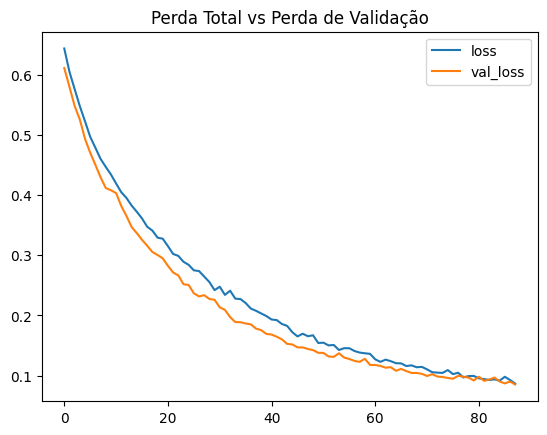

In [ ]:
plot_metric(model_pipeline, 'loss', 'val_loss', 'Perda Total vs Perda de Validação')

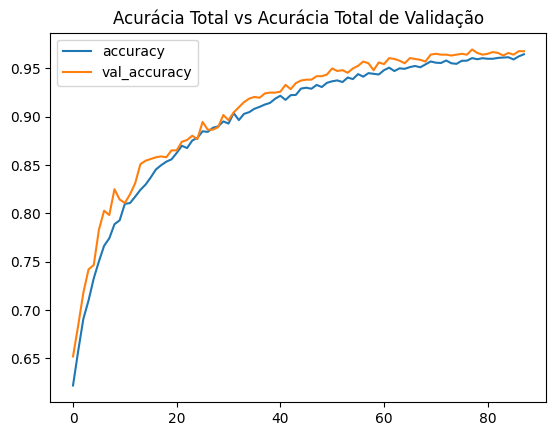

In [ ]:
plot_metric(model_pipeline, 'accuracy', 'val_accuracy', 'Acurácia Total vs Acurácia Total de Validação')

In [ ]:
labels_predict = model_pipeline.predict(features_test)

# Decoding the data to use in Metrics
labels_predict = (labels_predict > 0.5).astype(int)

# Se os rótulos de teste forem one-hot, converta para binários
labels_test_normal = np.argmax(labels_test, axis=1)

88/88 [==============================] - 7s 65ms/step


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(labels_test, labels_predict)

print("Acurácia:", accuracy_score(labels_test, labels_predict))
print("Precisão:", precision_score(labels_test, labels_predict))
print("Recall:", recall_score(labels_test, labels_predict))
print("F1-score:", f1)
print("Matriz de Confusão:\n", confusion_matrix(labels_test, labels_predict))

Acurácia: 0.9546428571428571
Precisão: 0.9549678341672623
Recall: 0.9542857142857143
F1-score: 0.9546266523758485
Matriz de Confusão:
 [[1337   63]
 [  64 1336]]


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(labels_test, labels_predict, target_names=['Violência', 'Não Violência'], digits=4)
print("Relatório de Classificação:\n", report)

Relatório de Classificação:
                precision    recall  f1-score   support

    Violência     0.9543    0.9550    0.9547      1400
Não Violência     0.9550    0.9543    0.9546      1400

     accuracy                         0.9546      2800
    macro avg     0.9546    0.9546    0.9546      2800
 weighted avg     0.9546    0.9546    0.9546      2800



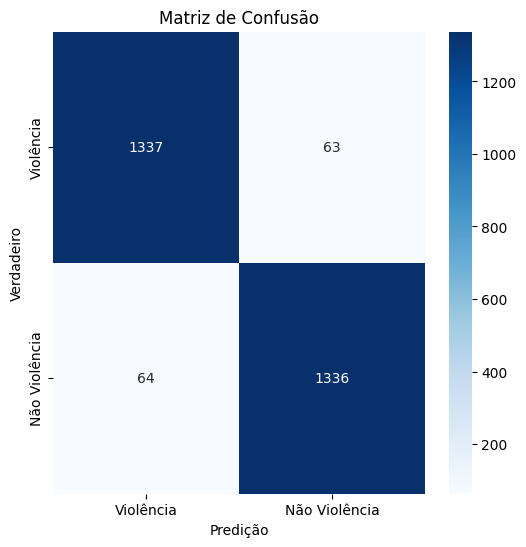

In [ ]:
import seaborn as sns

conf_matrix = confusion_matrix(labels_test, labels_predict)

# Passo 3: Exibir a matriz de confusão de forma visual
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Violência', 'Não Violência'], yticklabels=['Violência', 'Não Violência'])
plt.xlabel('Predição')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

AUC-ROC: 0.954642857142857


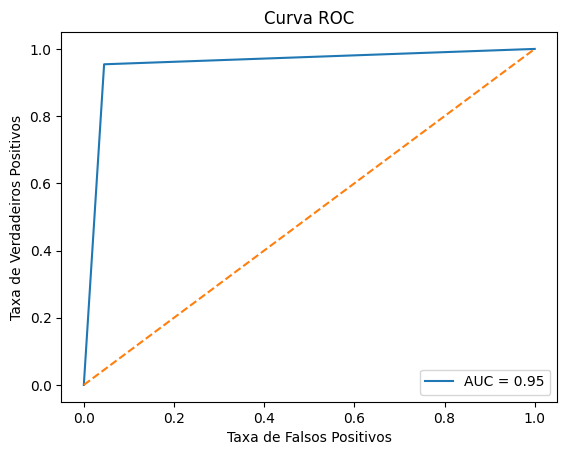

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# Calcule a AUC-ROC
auc_score = roc_auc_score(labels_test, labels_predict)
print("AUC-ROC:", auc_score)

# Curva ROC
fpr, tpr, thresholds = roc_curve(labels_test, labels_predict)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(labels_test, labels_predict).ravel()
specificity = tn / (tn + fp)
print("Especificidade:", specificity)

Especificidade: 0.955


In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(labels_test, labels_predict)
print("Acurácia Balanceada:", balanced_acc)

Acurácia Balanceada: 0.9546428571428571


In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(labels_test, labels_predict)
print("MCC:", mcc)

MCC: 0.9092859462464444


In [ ]:
from sklearn.metrics import log_loss

log_loss_value = log_loss(labels_test, labels_predict)
print("Log Loss:", log_loss_value)

Log Loss: 1.634837135863528


In [ ]:
model_pipeline.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 20, 64, 64, 3)]      0         []                            
                                                                                                  
 tf.compat.v1.zeros_like (T  (None, 20, 64, 64, 3)        0         ['input_1[0][0]']             
 FOpLambda)                                                                                       
                                                                                                  
 tf.math.reduce_sum (TFOpLa  (None, 64, 64, 3)            0         ['tf.compat.v1.zeros_like[0][0
 mbda)                                                              ]']                           
                                                                                              

In [ ]:
model_pipeline.save_weights("2sepconvlstm-sepconv2d-80epochs-reduced2x.h5")